In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['Brent Oil Futures Historical Data.csv'].decode('utf-8')))

Saving Brent Oil Futures Historical Data.csv to Brent Oil Futures Historical Data.csv


In [3]:
# Changing the format of the 'Date'column from object to datetime format
data['Date']=pd.to_datetime(data['Date'], infer_datetime_format=True)

In [4]:
# Convert "Vol." column to float datatype with suffix conversion
data['Vol.'] = data['Vol.'].str.replace('M', 'e6').str.replace('K', 'e3').astype(float)
print(data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [5]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date     0
Price    0
Open     0
High     0
Low      0
Vol.     0
dtype: int64


<ipython-input-6-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1200 non-null   datetime64[ns]
 1   Price   1200 non-null   float64       
 2   Open    1200 non-null   float64       
 3   High    1200 non-null   float64       
 4   Low     1200 non-null   float64       
 5   Vol.    1200 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 56.4 KB


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

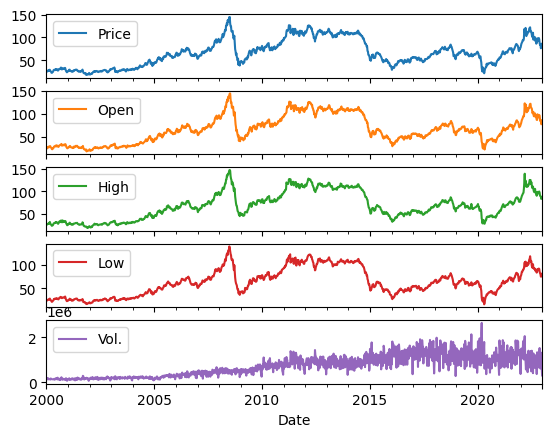

In [8]:
# Checking the correlation of each attribute with the date column
data.set_index('Date')[['Price','Open','High','Low', 'Vol.']].plot(subplots=True)

In [9]:
# Created a new dataframe which has all the columns
data_input=data[["Price",'Open','High','Low','Vol.']]
data_input

,Price,Open,High,Low,Vol.
0,85.91,84.50,86.00,81.28,299200.0
1,83.92,79.21,84.12,78.28,755000.0
2,79.04,76.88,83.18,75.26,1110000.0
3,76.10,85.73,88.44,75.11,1320000.0
4,85.57,83.58,89.37,80.61,607400.0
...,...,...,...,...,...
1195,27.07,25.40,27.10,25.21,185630.0
1196,25.68,26.68,26.95,25.38,171390.0
1197,26.35,25.55,27.11,25.42,188490.0
1198,25.47,23.04,25.56,23.04,103380.0


In [10]:
data_input.describe()

,Price,Open,High,Low,Vol.
count,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03
mean,65.895942,65.839650,67.924900,63.574717,7.381304e+05
std,29.469753,29.481392,30.081627,28.719811,4.899595e+05
min,17.750000,17.400000,18.700000,15.980000,6.006000e+04
25%,43.130000,42.955000,44.897500,40.435000,2.568250e+05
50%,63.100000,62.940000,64.870000,60.960000,6.694150e+05
75%,86.152500,86.350000,89.317500,83.545000,1.112500e+06
max,144.490000,144.400000,147.500000,139.540000,2.640000e+06


In [11]:
# Standardisation of the dataset to have a standard mean so that the gradience converges faster
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_input)
data_scaled

array([[0.53779391, 0.52834646, 0.52251553, 0.52848818, 0.09269208],
       [0.52209247, 0.48669291, 0.50791925, 0.50420848, 0.26936285],
       [0.48358845, 0.46834646, 0.50062112, 0.47976691, 0.40696295],
       ...,
       [0.06785545, 0.06417323, 0.06529503, 0.07640013, 0.04978023],
       [0.0609121 , 0.04440945, 0.05326087, 0.05713823, 0.01679109],
       [0.0421335 , 0.0511811 , 0.04658385, 0.05721916, 0.03188059]])

In [12]:
from pandas.core.tools.datetimes import YearMonthDayDict
# Extracting the target variable 
X=data_scaled #attributes include all the columns including the target
y=data_scaled[:,0] #target only the first column = price

In [13]:
# Taking two weeks data points to predict the third, hence length=2. 
TimeseriesGenerator(X, y, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.53779391, 0.52834646, 0.52251553, 0.52848818, 0.09269208],
         [0.52209247, 0.48669291, 0.50791925, 0.50420848, 0.26936285]]]),
 array([0.48358845]))

In [14]:
# Splitting the dataset in 80% train and 0.2% test dataset. 
# Shuffle=False because its a time series data
# x_train, x_test, y_train, y_test= train_test_split(features, target, test_size=0.2, random_state=42, shuffle=False)

In [15]:
# Addition
# Select the rows for the training set (2000-2019)
x_train = X[data['Date'].dt.year.between(2000, 2019)]
y_train = y[data['Date'].dt.year.between(2000, 2019)]

# Select the rows for the test set (2020-2022)
x_test = X[data['Date'].dt.year.between(2020, 2022)]
y_test = y[data['Date'].dt.year.between(2020, 2022)]

In [16]:
x_train.shape, x_test.shape

((1044, 5), (156, 5))

In [17]:
# Define TimeSeries Generator
win_length=4 #weekly dataset, so one month we have 4 datapoints
batch_size=16
num_features=5
train_generator= TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator= TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [18]:
train_generator[0] #32 observation cause of batch_size and each having window length of 4

(array([[[0.40121509, 0.4       , 0.39440994, 0.40182907, 0.32006558],
         [0.39774341, 0.38385827, 0.38532609, 0.40328585, 0.13947224],
         [0.38180527, 0.37519685, 0.37329193, 0.39575915, 0.42634325],
         [0.37454632, 0.3692126 , 0.36560559, 0.3806248 , 0.44184748]],
 
        [[0.39774341, 0.38385827, 0.38532609, 0.40328585, 0.13947224],
         [0.38180527, 0.37519685, 0.37329193, 0.39575915, 0.42634325],
         [0.37454632, 0.3692126 , 0.36560559, 0.3806248 , 0.44184748],
         [0.36799748, 0.3411811 , 0.35854037, 0.35869213, 0.54650108]],
 
        [[0.38180527, 0.37519685, 0.37329193, 0.39575915, 0.42634325],
         [0.37454632, 0.3692126 , 0.36560559, 0.3806248 , 0.44184748],
         [0.36799748, 0.3411811 , 0.35854037, 0.35869213, 0.54650108],
         [0.35253274, 0.36377953, 0.35636646, 0.3753642 , 0.2225982 ]],
 
        [[0.37454632, 0.3692126 , 0.36560559, 0.3806248 , 0.44184748],
         [0.36799748, 0.3411811 , 0.35854037, 0.35869213, 0.54650108

In [19]:
# LSTM model architecture
from tensorflow.keras import regularizers

# LSTM model architecture
model = tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape=(win_length, num_features), return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5)) # LeakyReLU activation function
model.add(tf.keras.layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout rate for stronger regularization
model.add(tf.keras.layers.LSTM(128, return_sequences=False, kernel_regularizer=regularizers.l1_l2(l1=0.01, l2=0.01)))
model.add(tf.keras.layers.Dropout(0.5))  # Increased dropout rate for stronger regularization
model.add(tf.keras.layers.Dense(1))

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            68608     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 4, 128)            131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 128)            0         
                                                                 
 dropout (Dropout)           (None, 4, 128)            0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [21]:
# Defining the model
# early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')

model.compile(loss=tf.losses.MeanSquaredError(), optimizer=tf.optimizers.Nadam(), metrics=[tf.metrics.MeanAbsoluteError()])

history=model.fit_generator(train_generator, epochs= 100, validation_data=test_generator, shuffle=False) #, callbacks=[early_stopping])

Epoch 1/100


<ipython-input-21-23af3bb68b41>:6: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history=model.fit_generator(train_generator, epochs= 100, validation_data=test_generator, shuffle=False) #, callbacks=[early_stopping])


65/65 [==============================] - 8s 31ms/step - loss: 37.3743 - mean_absolute_error: 0.1681 - val_loss: 10.6468 - val_mean_absolute_error: 0.3245
Epoch 2/100
65/65 [==============================] - 1s 16ms/step - loss: 2.4940 - mean_absolute_error: 0.2096 - val_loss: 0.2352 - val_mean_absolute_error: 0.2856
Epoch 3/100
65/65 [==============================] - 1s 20ms/step - loss: 0.1909 - mean_absolute_error: 0.2336 - val_loss: 0.2223 - val_mean_absolute_error: 0.2669
Epoch 4/100
65/65 [==============================] - 1s 16ms/step - loss: 0.2002 - mean_absolute_error: 0.2473 - val_loss: 0.2046 - val_mean_absolute_error: 0.2381
Epoch 5/100
65/65 [==============================] - 1s 15ms/step - loss: 0.1985 - mean_absolute_error: 0.2423 - val_loss: 0.1968 - val_mean_absolute_error: 0.2273
Epoch 6/100
65/65 [==============================] - 1s 15ms/step - loss: 0.1998 - mean_absolute_error: 0.2419 - val_loss: 0.1868 - val_mean_absolute_error: 0.2141
Epoch 7/100
65/65 [=======

In [22]:
# Checking on models on the test part
model.evaluate_generator(test_generator)

<ipython-input-22-fb2167925083>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(test_generator)


[0.29719457030296326, 0.34551915526390076]

In [23]:
predictions=model.predict_generator(test_generator)

<ipython-input-23-6ca49477046f>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(test_generator)


In [26]:
# Test data had 156 datapoints and 4 win_length hence the prediction shape is 152
predictions.shape[0]

152

In [27]:
predictions

array([[0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497816],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497816],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497816],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497814],
       [0.07497816],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497814],
       [0.07497816],
       [0.07497816],
       [0.07497814],
       [0.07497816],
       [0.07497816],
       [0.074

In [28]:
x_test, y_test

(array([[0.53779391, 0.52834646, 0.52251553, 0.52848818, 0.09269208],
        [0.52209247, 0.48669291, 0.50791925, 0.50420848, 0.26936285],
        [0.48358845, 0.46834646, 0.50062112, 0.47976691, 0.40696295],
        [0.46039135, 0.5380315 , 0.54145963, 0.47855293, 0.48836019],
        [0.53511125, 0.52110236, 0.54868012, 0.52306572, 0.21215222],
        [0.51980432, 0.55385827, 0.55279503, 0.53682421, 0.33273642],
        [0.5512861 , 0.61787402, 0.60753106, 0.5650696 , 0.56588138],
        [0.61732681, 0.6292126 , 0.62779503, 0.61306248, 0.48836019],
        [0.63768345, 0.62259843, 0.62197205, 0.61791842, 0.3837066 ],
        [0.61559097, 0.59992126, 0.61001553, 0.60893493, 0.23146662],
        [0.59768029, 0.58511811, 0.59060559, 0.58910651, 0.45735172],
        [0.58292567, 0.64055118, 0.62150621, 0.60780188, 0.4495996 ],
        [0.63255484, 0.54291339, 0.62018634, 0.56952088, 0.49223625],
        [0.55396875, 0.54503937, 0.55450311, 0.54766915, 0.11694846],
        [0.53968755,

In [29]:
# Creating a dataframe from the x_test which include the variables accept the 1st column
x_test[:,1][win_length:]

array([0.52110236, 0.55385827, 0.61787402, 0.6292126 , 0.62259843,
       0.59992126, 0.58511811, 0.64055118, 0.54291339, 0.54503937,
       0.58291339, 0.59165354, 0.59543307, 0.65566929, 0.61850394,
       0.63244094, 0.60716535, 0.68125984, 0.68070866, 0.65685039,
       0.70551181, 0.74212598, 0.75212598, 0.75968504, 0.82314961,
       0.82007874, 0.80220472, 0.7515748 , 0.74228346, 0.75228346,
       0.7       , 0.69362205, 0.74740157, 0.67566929, 0.68251969,
       0.80708661, 0.70944882, 0.75393701, 0.82984252, 0.66598425,
       0.60543307, 0.61259843, 0.59330709, 0.57795276, 0.55535433,
       0.54133858, 0.50677165, 0.4780315 , 0.46393701, 0.43637795,
       0.45645669, 0.41606299, 0.44472441, 0.48173228, 0.5080315 ,
       0.51322835, 0.52149606, 0.53740157, 0.53188976, 0.51377953,
       0.48889764, 0.47913386, 0.45614173, 0.43685039, 0.43440945,
       0.43976378, 0.37456693, 0.41456693, 0.41622047, 0.45661417,
       0.44661417, 0.43669291, 0.45976378, 0.46322835, 0.46133

In [30]:
# Make prediction on the the previous dataframe
data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)
data.pred # Scaled values

<ipython-input-30-d0c09e8effeb>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)


,0,0,1,2,3
0,0.074978,0.521102,0.548680,0.523066,0.212152
1,0.074978,0.553858,0.552795,0.536824,0.332736
2,0.074978,0.617874,0.607531,0.565070,0.565881
3,0.074978,0.629213,0.627795,0.613062,0.488360
4,0.074978,0.622598,0.621972,0.617918,0.383707
...,...,...,...,...,...
147,0.074978,0.305197,0.295575,0.305196,0.732552
148,0.074978,0.337244,0.325466,0.337731,0.277224
149,0.074978,0.382520,0.367236,0.358287,0.480608
150,0.074978,0.375827,0.364130,0.384995,0.449600


In [31]:
# Perform the reverse transform on the above scaled dataset
rev_trans=scaler.inverse_transform(data.pred)
rev_trans # Hence values are reversed to get the actual value

array([[2.72527298e+01, 8.35800000e+01, 8.93700000e+01, 8.06100000e+01,
        6.07400000e+05],
       [2.72527298e+01, 8.77400000e+01, 8.99000000e+01, 8.23100000e+01,
        9.18500000e+05],
       [2.72527317e+01, 9.58700000e+01, 9.69500000e+01, 8.58000000e+01,
        1.52000000e+06],
       [2.72527317e+01, 9.73100000e+01, 9.95600000e+01, 9.17300000e+01,
        1.32000000e+06],
       [2.72527298e+01, 9.64700000e+01, 9.88100000e+01, 9.23300000e+01,
        1.05000000e+06],
       [2.72527298e+01, 9.35900000e+01, 9.72700000e+01, 9.12200000e+01,
        6.57230000e+05],
       [2.72527298e+01, 9.17100000e+01, 9.47700000e+01, 8.87700000e+01,
        1.24000000e+06],
       [2.72527298e+01, 9.87500000e+01, 9.87500000e+01, 9.10800000e+01,
        1.22000000e+06],
       [2.72527298e+01, 8.63500000e+01, 9.85800000e+01, 8.63500000e+01,
        1.33000000e+06],
       [2.72527298e+01, 8.66200000e+01, 9.01200000e+01, 8.36500000e+01,
        3.61780000e+05],
       [2.72527298e+01, 9.1430

In [32]:
# Making final prediction. Count also matches the test dataframe
data_final=data_input[predictions.shape[0]*-1:]
data_final, data_final.count()

(      Price   Open   High    Low      Vol.
 1048  25.16  25.51  25.71  24.65  169350.0
 1049  25.21  23.59  25.33  23.52  222070.0
 1050  23.35  23.75  24.30  22.56  185180.0
 1051  23.58  25.25  25.54  23.25  256900.0
 1052  25.41  25.60  26.05  25.05  187920.0
 ...     ...    ...    ...    ...       ...
 1195  27.07  25.40  27.10  25.21  185630.0
 1196  25.68  26.68  26.95  25.38  171390.0
 1197  26.35  25.55  27.11  25.42  188490.0
 1198  25.47  23.04  25.56  23.04  103380.0
 1199  23.09  23.90  24.70  23.05  142310.0
 
 [152 rows x 5 columns],
 Price    152
 Open     152
 High     152
 Low      152
 Vol.     152
 dtype: int64)

In [33]:
# Adding the reversed predicted column in the original dataframe
data_final['Price Predicted']=rev_trans[:,0]
data_final

<ipython-input-33-0ad126213f07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['Price Predicted']=rev_trans[:,0]


,Price,Open,High,Low,Vol.,Price Predicted
1048,25.16,25.51,25.71,24.65,169350.0,27.252730
1049,25.21,23.59,25.33,23.52,222070.0,27.252730
1050,23.35,23.75,24.30,22.56,185180.0,27.252732
1051,23.58,25.25,25.54,23.25,256900.0,27.252732
1052,25.41,25.60,26.05,25.05,187920.0,27.252730
...,...,...,...,...,...,...
1195,27.07,25.40,27.10,25.21,185630.0,27.252732
1196,25.68,26.68,26.95,25.38,171390.0,27.252730
1197,26.35,25.55,27.11,25.42,188490.0,27.252730
1198,25.47,23.04,25.56,23.04,103380.0,27.252730


<Axes: >

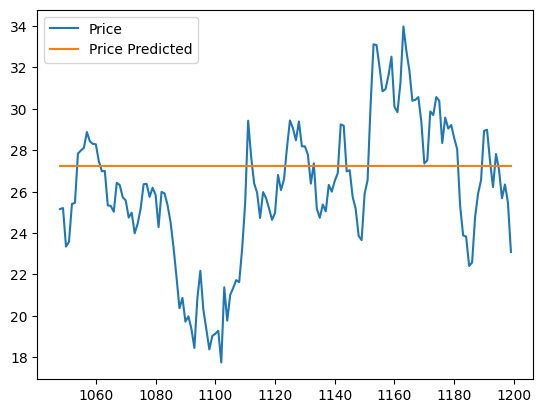

In [48]:
# Checking the prediction with the original price with the predicted price
data_final[['Price','Price Predicted']].plot()

In [49]:
!pip install dmba
from dmba import regressionSummary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.3 MB/s eta 0:00:00
no display found. Using non-interactive Agg backend


In [50]:
regressionSummary(data_final.Price, data_final['Price Predicted'])


Regression statistics

                      Mean Error (ME) : -1.1302
       Root Mean Squared Error (RMSE) : 3.5544
            Mean Absolute Error (MAE) : 2.7673
          Mean Percentage Error (MPE) : -6.2240
Mean Absolute Percentage Error (MAPE) : 11.5715
